# 1. Model (improved)

Classification Report:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8858695652173914
Precision: 0.8872051588884458
Recall: 0.8858695652173914
F1-Score: 0.8852184150325296


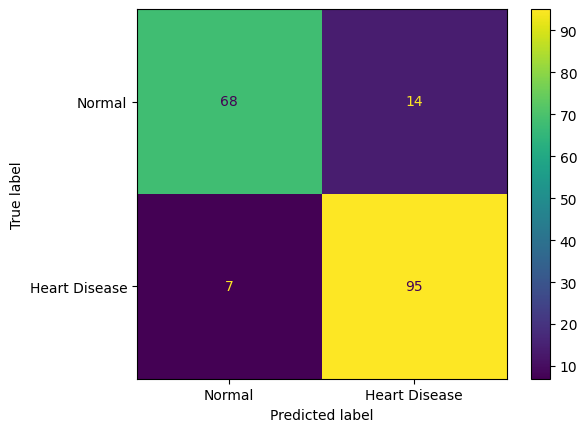

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

train = pd.read_csv("../1-Data/train_processed.csv")
x_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]

C = 0.01 # Regularization strength
threshold = 0.45 # Adjust the threshold for classifying as heart disease

model = LogisticRegression(C=C, random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = (model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()

# 2. Error analysis

In [12]:
# --- PHẦN SỬA LẠI ĐỂ TÌM CÁC TRƯỜNG HỢP SAI VỚI DỮ LIỆU GỐC ---

# Lấy xác suất dự đoán để phân tích thêm
y_proba = model.predict_proba(x_test)[:, 1]

# 1. Đọc dữ liệu test gốc (chưa qua chuẩn hóa)
# Đảm bảo đường dẫn này trỏ đúng vào file dữ liệu gốc của bạn
test_original = pd.read_csv("../1-Data/test_data.csv")

# 2. Tạo một DataFrame chứa dữ liệu GỐC để dễ quan sát
error_df = test_original.copy()
error_df['True_Label'] = y_test.values
error_df['Predicted_Label'] = y_pred
error_df['Predicted_Prob'] = y_proba

# 3. Lọc ra các dòng dự đoán sai (True_Label khác Predicted_Label)
incorrect_cases = error_df[error_df['True_Label'] != error_df['Predicted_Label']]

print(f"\nTổng số ca dự đoán sai: {len(incorrect_cases)}")

# Chia làm 2 nhóm để dễ phân tích 3 lỗi sai (Error Analysis):

# NHÓM 1: False Positives (Thực tế là 0 - Normal, nhưng đoán là 1 - Heart Disease)
false_positives = incorrect_cases[(incorrect_cases['True_Label'] == 0) & (incorrect_cases['Predicted_Label'] == 1)]
print(f"\n--- FALSE POSITIVES (Dữ liệu gốc - Đoán nhầm người khỏe là có bệnh): {len(false_positives)} ca ---")
# Dùng .head() để in ra 5 ca đầu tiên cho dễ nhìn, bạn có thể xóa .head() nếu muốn in toàn bộ
print(false_positives.head()) 

# NHÓM 2: False Negatives (Thực tế là 1 - Heart Disease, nhưng đoán là 0 - Normal)
false_negatives = incorrect_cases[(incorrect_cases['True_Label'] == 1) & (incorrect_cases['Predicted_Label'] == 0)]
print(f"\n--- FALSE NEGATIVES (Dữ liệu gốc - Bỏ sót người có bệnh): {len(false_negatives)} ca ---")
print(false_negatives.head())

# Nếu muốn xuất ra file Excel/CSV để dễ nhìn và copy vào slide báo cáo:
incorrect_cases.to_csv("incorrect_predictions.csv", index=False)


Tổng số ca dự đoán sai: 21

--- FALSE POSITIVES (Dữ liệu gốc - Đoán nhầm người khỏe là có bệnh): 14 ca ---
    Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
47   41    1        135          203          0    132               0   
49   44    1        120          184          0    142               0   
50   53    1         80            0          0    141               1   
55   41    1        130          214          0    168               0   
72   51    0        114          258          1     96               0   

    Oldpeak  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
47      0.0                  1                  0                 0   
49      1.0                  1                  0                 0   
50      2.0                  0                  0                 0   
55      2.0                  0                  1                 0   
72      1.0                  0                  0                 0   

    RestingECG_Norma

PermissionError: [Errno 13] Permission denied: 'incorrect_predictions.csv'

anh phân tích ở đây